## Сессия 6 - Визуализация

In [1]:
import pandas as pd
# Загрузим датафрейм в котором отсутствуют выбросы, обнаруженные на предыдущем этапе
data = pd.read_csv('data_from_notes/outlier_free_data.csv', sep = ';')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87617 entries, 0 to 87616
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       87617 non-null  object 
 1   customer_id                    87617 non-null  object 
 2   order_status                   87617 non-null  object 
 3   order_purchase_timestamp       87617 non-null  object 
 4   order_approved_at              87605 non-null  object 
 5   order_delivered_carrier_date   86622 non-null  object 
 6   order_delivered_customer_date  85642 non-null  object 
 7   order_estimated_delivery_date  87617 non-null  object 
 8   customer_unique_id             87617 non-null  object 
 9   customer_zip_code_prefix       87617 non-null  int64  
 10  customer_city                  87617 non-null  object 
 11  customer_state                 87617 non-null  object 
 12  payment_sequential             87617 non-null 

In [2]:
# Приведем дату к нужному формату

cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date',
        'review_answer_timestamp', 'delivery_days']

for col in cols:
    data[col] = pd.to_datetime(data[col], format = 'mixed')

# Проверим, все ли данные в нужном формате
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87617 entries, 0 to 87616
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87617 non-null  object        
 1   customer_id                    87617 non-null  object        
 2   order_status                   87617 non-null  object        
 3   order_purchase_timestamp       87617 non-null  datetime64[ns]
 4   order_approved_at              87605 non-null  datetime64[ns]
 5   order_delivered_carrier_date   86622 non-null  datetime64[ns]
 6   order_delivered_customer_date  85642 non-null  datetime64[ns]
 7   order_estimated_delivery_date  87617 non-null  datetime64[ns]
 8   customer_unique_id             87617 non-null  object        
 9   customer_zip_code_prefix       87617 non-null  int64         
 10  customer_city                  87617 non-null  object        
 11  customer_state 

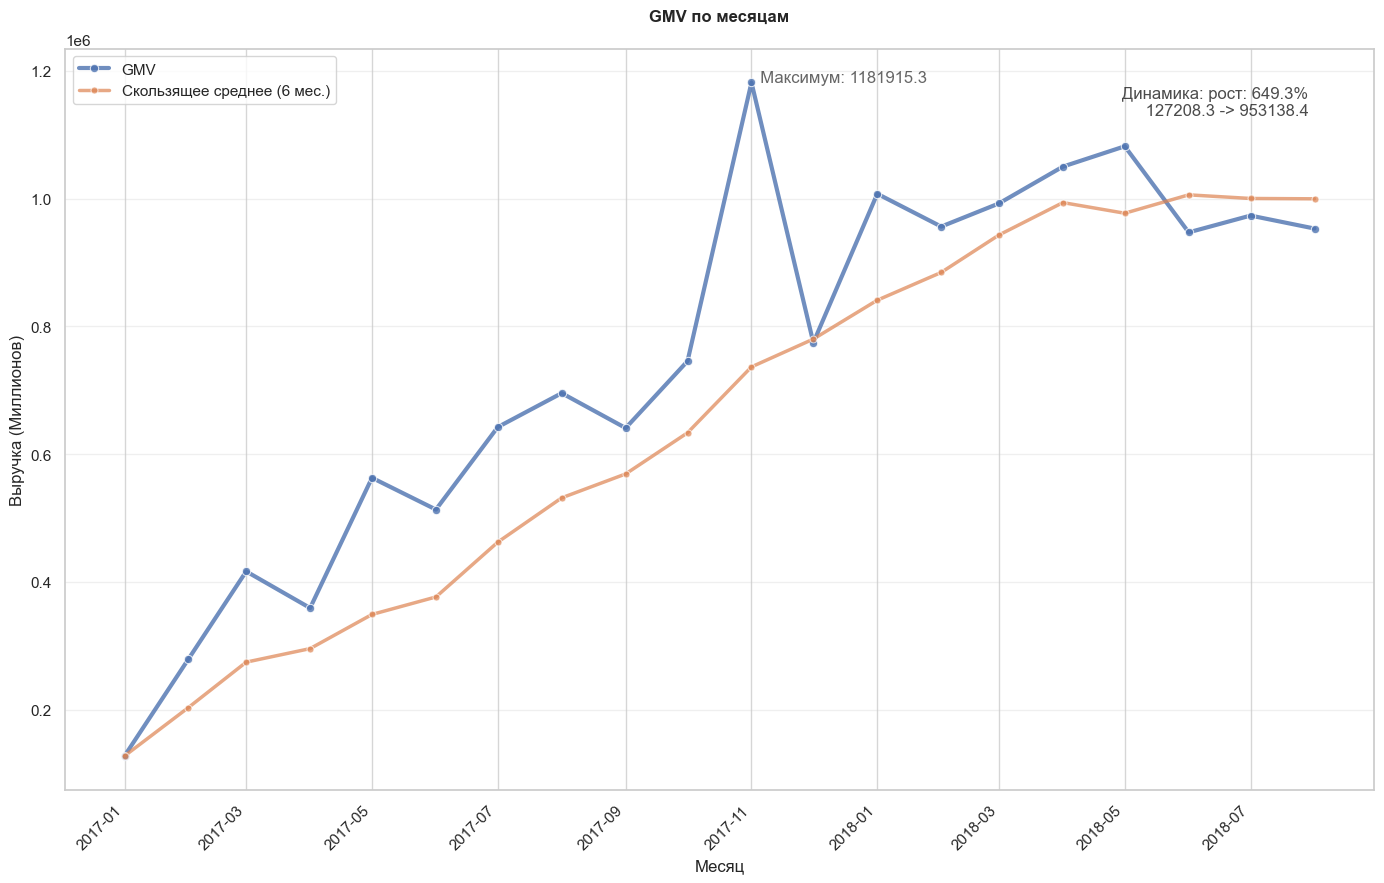

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from style import setup_style, decorate

# Построим первый график, отражающий GMV, рассчитанное по месяцам
start_date = '2017-01-01'
end_date = '2018-08-31'
date_mask = (data['order_purchase_timestamp'] >= start_date) & (data['order_purchase_timestamp'] <= end_date)
prepared_data = data[date_mask].copy()
data_for_gmv = prepared_data.groupby(['order_id', 'order_purchase_timestamp'])['payment_value'].sum().reset_index()
data_for_gmv['month'] = prepared_data['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
gmv_per_month = data_for_gmv.groupby('month')['payment_value'].sum().reset_index()

# Также, отразим скользящее среднее для большей информативности визуализации
gmv_per_month['ma6'] = gmv_per_month['payment_value'].rolling(window = 6, min_periods = 1).mean()

fig, ax = plt.subplots(figsize = (14, 9))
sns.set_theme(style = 'whitegrid')
sns.lineplot(x = 'month', y = 'payment_value', linewidth = 3, marker = 'o', alpha = 0.8, data = gmv_per_month, label = 'GMV')
sns.lineplot(x = 'month', y = 'ma6', linewidth = 2.5, marker = 'o', markersize = 5, alpha = 0.7, data = gmv_per_month, label = 'Скользящее среднее (6 мес.)')

# Выделим пиковые продажи:
max_row = gmv_per_month.loc[gmv_per_month['payment_value'].idxmax()]
ax.text(max_row['month'], max_row['payment_value'] + 20, f'  Максимум: {max_row['payment_value']:.1f}', ha = 'left', alpha = 0.7)

# Также отобразим краткую сводку о полученных данных:
first_value = gmv_per_month['payment_value'].iloc[0]
last_value = gmv_per_month['payment_value'].iloc[-1]
gth = ((last_value - first_value) / first_value) * 100
if gth > 0:
    text = f'рост: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'
elif gth < 0: 
    text = f'падение: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'

ax.text(
    0.95, 0.95,
    f'Динамика: {text}',
    transform=ax.transAxes,
    color = 'black',
    alpha = 0.7,
    ha = 'right',
    va = 'top'
)

plt.legend()
decorate(ax, 'GMV по месяцам', 'Месяц', 'Выручка (Миллионов)')
plt.xticks(rotation = 45, ha = 'right')
ax.grid(axis = 'x', alpha = 0.8)
plt.tight_layout()
plt.savefig('plots/gmv_per_month.png', dpi = 300)
# Очистим память, удалив из неё созданные датафреймы
del data_for_gmv
del gmv_per_month

**Инсайт по графику:** Исходя из графика видно, что выручка площадки планомерно растет из месяца в месяц с резким скачком 2017-11, что вероятно связано с проведением черной пятницы, подтверждает это и последующее охлаждение 2017-12. Начиная с 2018 года темпы росты компании заметно снизились и перешли к стагнации, что может быть связано с тем, что компания плохо удерживает постоянных клиентов и в среднем человек покупает на площадке 1 лишь раз, поэтому для дальнейшего роста, как уже было рекомендовано необходимо использовать Retetion-маркетинг.

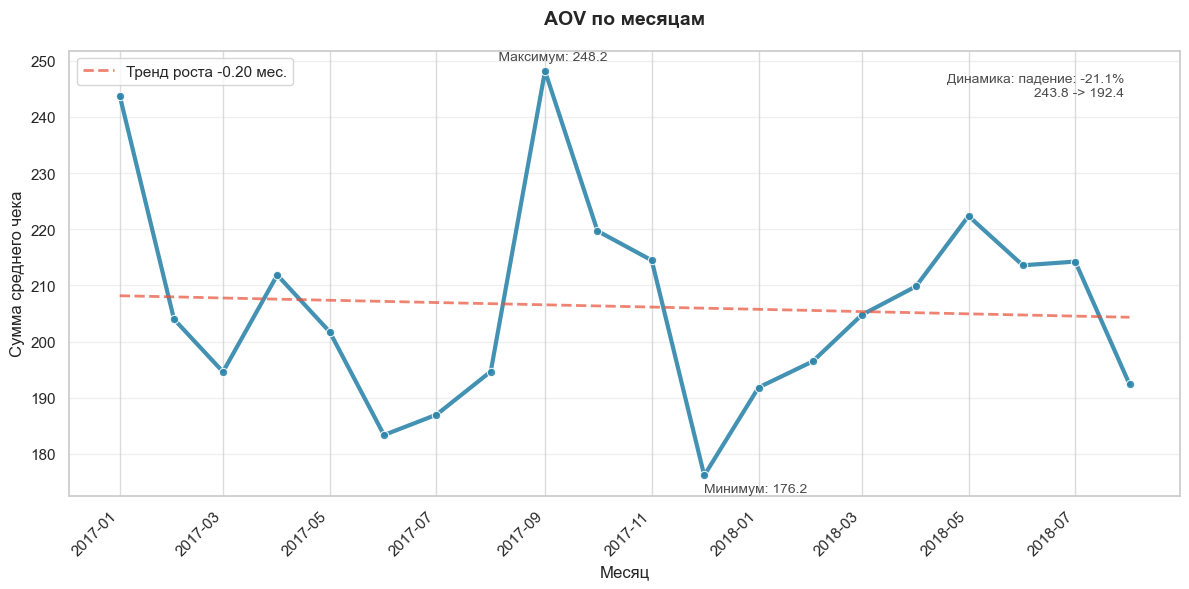

<Figure size 1000x600 with 0 Axes>

In [56]:
## Оформление графиков AOV и ARPU, основанных на данных с 2017-01 по 2018-08-31 
import numpy as np
from style import setup_style, decorate 
data_aov_arpu = prepared_data.groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp'])['payment_value'].sum().reset_index()
data_aov_arpu['month'] = data_aov_arpu['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
aov_arpu = data_aov_arpu.groupby('month').agg(
   revenue = ('payment_value', 'sum'),
   orders = ('order_id', 'count'),
   customers = ('customer_unique_id', 'nunique')
).reset_index()
aov_arpu['aov'] = aov_arpu['revenue'] / aov_arpu['orders']
aov_arpu['arpu'] = aov_arpu['revenue'] / aov_arpu['customers']

fig, ax = plt.subplots(figsize = (12, 6))

setup_style()
sns.lineplot(x = 'month', y = 'aov', marker = 'o', linewidth = 3, alpha = 0.9, data = aov_arpu, ax = ax)

# Построим тренд роста для большей наглядности графика в условиях высокой ваолатильности
x = np.arange(len(aov_arpu))
slope, intercept = np.polyfit(x, aov_arpu['aov'].dropna(), 1)
trend = intercept + slope * x
ax.plot(aov_arpu['month'], trend, '--', linewidth = 2, alpha = 0.7, label = f'Тренд роста {slope:.2f} мес.')
# Обозначим пиковые значения 
max_row = aov_arpu.loc[aov_arpu['aov'].idxmax()]
min_row = aov_arpu.loc[aov_arpu['aov'].idxmin()]

ax.text(max_row['month'], max_row['aov'] + 2 , f'    Максимум: {max_row['aov']:.1f}', ha = 'center', color = 'black', alpha = 0.7)
ax.text(min_row['month'], min_row['aov'] - 3 , f'Минимум: {min_row['aov']:.1f}', ha = 'left', color = 'black', alpha = 0.7)

# Отразим краткую сводку о полученных данных
first_value = aov_arpu['aov'].iloc[0]
last_value = aov_arpu['aov'].iloc[-1]
gth = ((last_value - first_value) / first_value) * 100
if gth > 0:
    text = f'рост: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'
elif gth < 0: 
    text = f'падение: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'

ax.text(
    0.95, 0.95,
    f'Динамика: {text}',
    transform=ax.transAxes,
    color = 'black',
    alpha = 0.7,
    ha = 'right',
    va = 'top'
)
decorate(ax, 'AOV по месяцам', 'Месяц', 'Сумма среднего чека')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
ax.grid(axis = 'x', alpha = 0.7)
plt.show()
plt.savefig('plots/aov_per_month.png', dpi = 300)

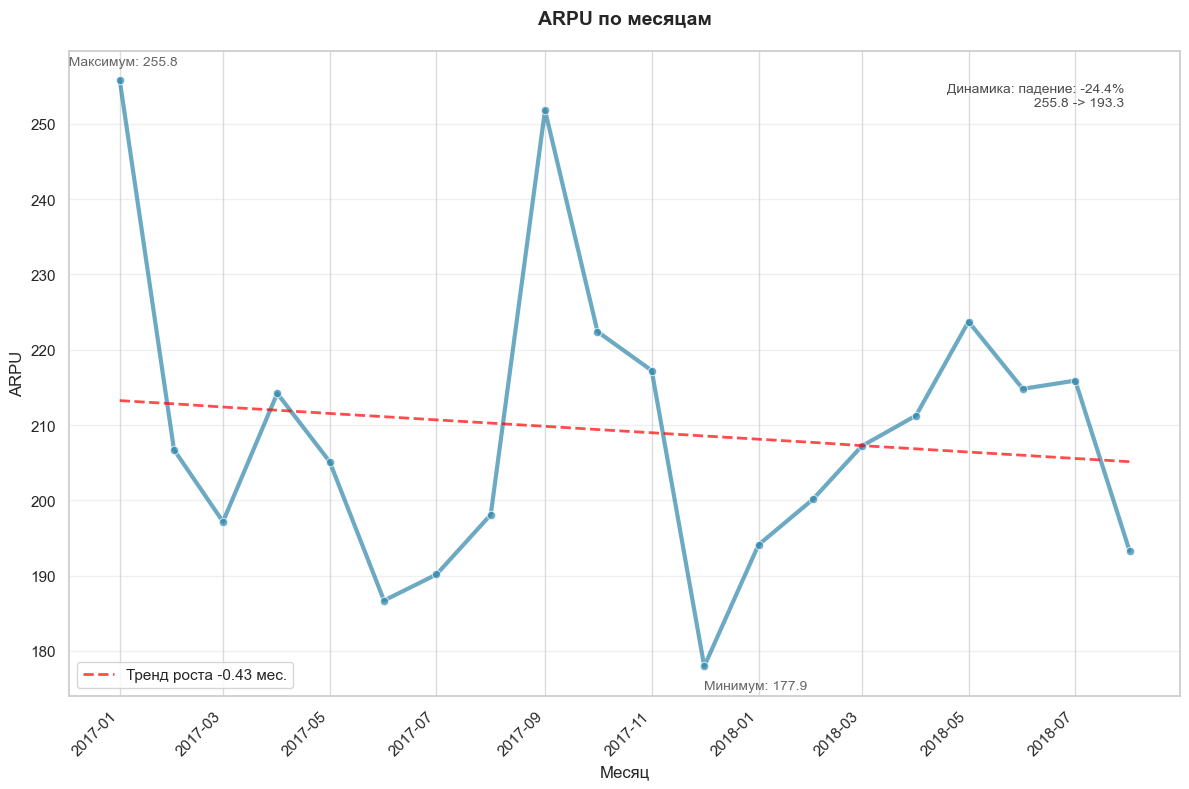

In [61]:
# Построим график ARPU по месяцам
setup_style()
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(x = 'month', y = 'arpu', marker = 'o', linewidth = 3, alpha = 0.7, data = aov_arpu)
# Также, построим тренд роста для ARPU
x = np.arange(len(aov_arpu))
slope, intercept = np.polyfit(x, aov_arpu['arpu'].dropna(), 1)
trend = intercept + slope * x
ax.plot(aov_arpu['month'], trend, '--', color = 'red', linewidth = 2, alpha = 0.7, label = f'Тренд роста {slope:.2f} мес.')

# Обозначим пиковые значения 
max_row = aov_arpu.loc[aov_arpu['arpu'].idxmax()]
min_row = aov_arpu.loc[aov_arpu['arpu'].idxmin()]

ax.text(max_row['month'], max_row['arpu'] + 2 , f'  Максимум: {max_row['arpu']:.1f}', ha = 'center', alpha = 0.7)
ax.text(min_row['month'], min_row['arpu'] - 3 , f'Минимум: {min_row['arpu']:.1f}', ha = 'left', alpha = 0.7)
first_value = aov_arpu['arpu'].iloc[0]
last_value = aov_arpu['arpu'].iloc[-1]
gth = ((last_value - first_value) / first_value) * 100
if gth > 0:
    text = f'рост: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'
elif gth < 0: 
    text = f'падение: {gth:.1f}%\n {first_value:.1f} -> {last_value:.1f}'

ax.text(
    0.95, 0.95,
    f'Динамика: {text}',
    transform=ax.transAxes,
    color = 'black',
    alpha = 0.7,
    ha = 'right',
    va = 'top'
)
decorate(ax, 'ARPU по месяцам', 'Месяц', 'ARPU')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
ax.grid(axis = 'x', alpha = 0.7)
plt.savefig('plots/arpu_per_month.png', dpi = 300)

**Инсайт по графикам:** Графики AOV и ARPU почти идентичны и показывают высокую волатильность, что может быть связано с сезонностью, так как летом люди склонны тратить меньше денег, а в акционные месяцы, такие как ноябрь, люди тратят больше. При этом стоит учесть, что тренд показывает падение средних показателей, что говорит о том, что компания растет экстенсивно, засчет привлечения новых клиентов, а не развития старых. При этом, известные проблемы компании, как возврат и удержание клиентов, сказываются и здесь. Начиная с 2018-го года падение среднего чека в совокупности с тем, что новых клиентов поступает меньше приводит как раз к замедлению выручки, что мы могли видеть на графике GMV. Компании рекомендуется развивать стратегии привлечение и удержания старых клиентов, разработка плана акций, программ лояльности и тд и тп. так как в ином случае есть риск того, что общая выручка, а также средний чек и средняя выручка с одного пользователя продолжат медленно, но планомерно снижатся, что в лучшем случае приведет к стагнации. 

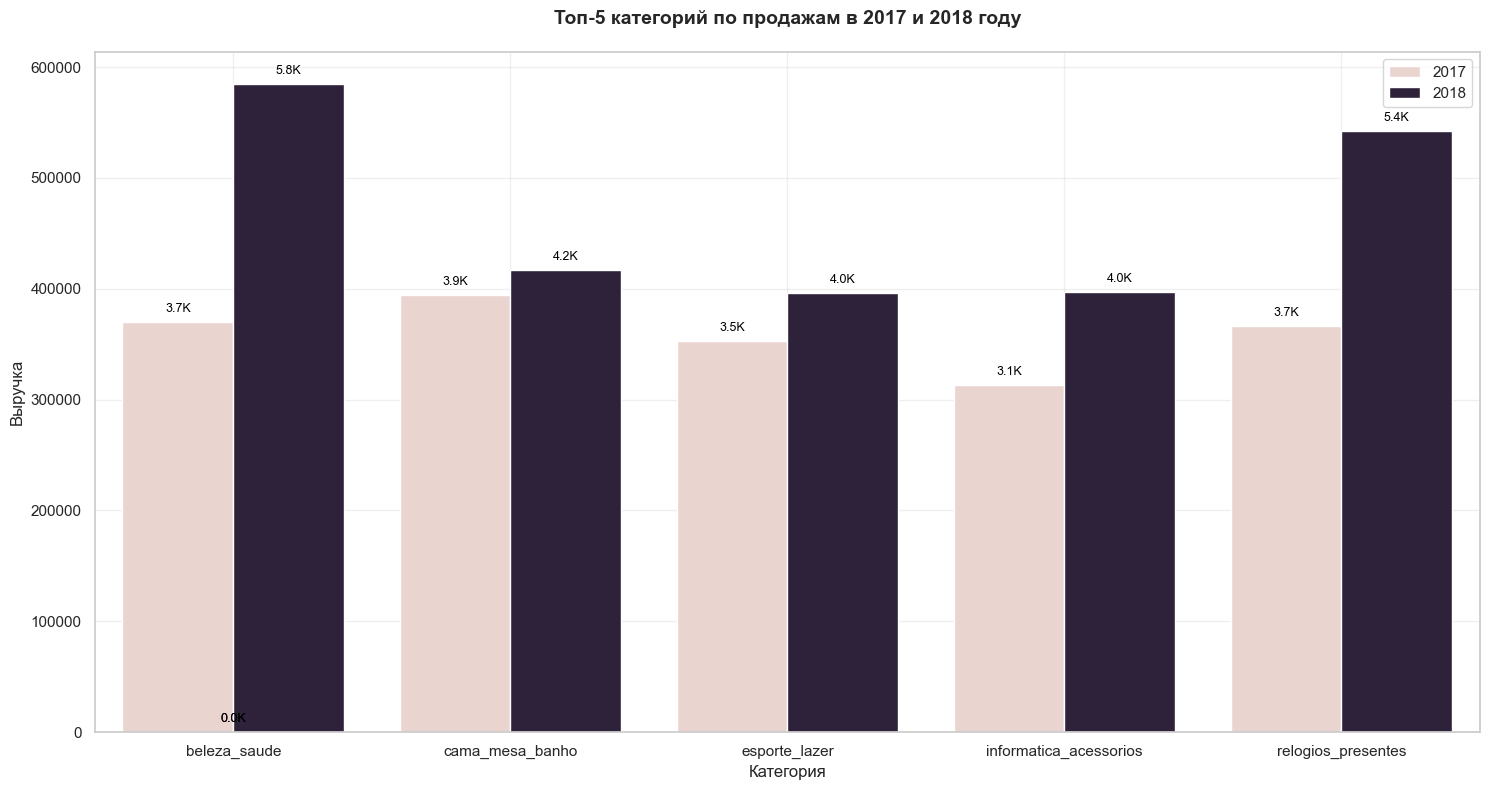

In [62]:
from style import setup_style, decorate
# Построим график по продажам топ-5 категориям в 2017 и 2018 году
# В качестве профилактики заполним NaN поля в названиях категорий на unknown
prepared_data['product_category_name'] = prepared_data['product_category_name'].fillna('unknown')

# Создадим столбец года продаж для дальнейшей группировки
prepared_data['year'] = prepared_data['order_purchase_timestamp'].dt.year

# Сгруппируем и подготовим данные для построения графика
# Найдем топ-5 категорий в 2017 и 2018 году
top_5_cats = prepared_data.groupby('product_category_name')['price'].sum()
top_5_names = top_5_cats.nlargest(5).index

# Отфильтруем данные, оставив только топ-5 категорий
filtered_top = prepared_data[prepared_data['product_category_name'].isin(top_5_names)]

#Окончательно сгруппируем данные по году и категории для построения графика
data_for_plot = filtered_top.groupby(['year', 'product_category_name'])['price'].sum().reset_index()

# Перейдем к построению графика
setup_style()
fig, ax = plt.subplots(figsize = (15, 8))
sns.barplot(x = 'product_category_name', y = 'price', hue = 'year', data = data_for_plot, ax = ax)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height/100000:.1f}K',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, color='black',
                xytext=(0, 5), 
                textcoords='offset points')
decorate(ax, 'Топ-5 категорий по продажам в 2017 и 2018 году', 'Категория', 'Выручка')    
plt.tight_layout()
plt.savefig('plots/top5_sales.png', dpi = 300)



**Инсайт по графику:** В 2017 и 2018 году топ категорий заняли одни и те же категории, сохранив при этом рост. Хедлайнер среди категорий - краосота и здорровье, продажи по ней значительно увеличись, что может свидетельствовать о формировании лица площадки и о том, как я её воспринимает широкий потребитель. Также, в 2018 году вырвалась в лидеры категория часы и подарки, необходимо поддерживать этот взрывно рост. В целом, видно, что площадка растет не за счет какой-то одной категории, а засчет плавного роста всех категорий, что дает площадке устойчивости в меняющемся рынке